# HW 4 Martine Maggi

Thanks for the due date leeway on this! I am glad I was able to take my time with it so I could understand each part thouroughly. It took a good bit of trial, error, googling, and cross-checking with Hannah.

## Part 1: 2D MCMC

Some of the groundwork was already done in the Intro To Linear Regression Notebook which used the same data.

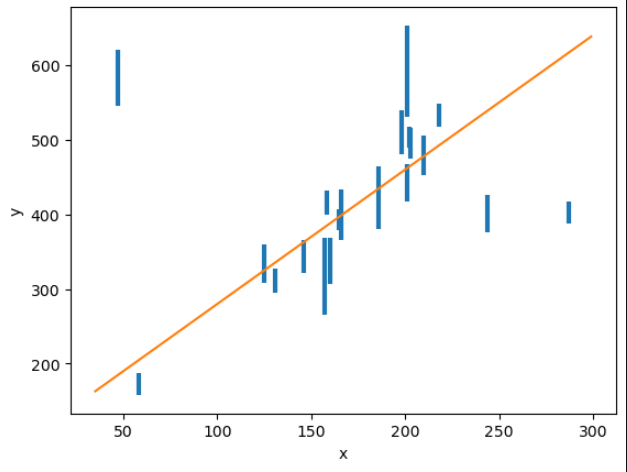

Via linear regression we see that the best fit line is **y = 1.08 x + 213.27**.

I construct a 2D MCMC sampler to optimize the values of **m** and **b**. With some minor adapting to the 1D case from the Intro to Sampling Notebook, we acheive fuzzy caterpillars!

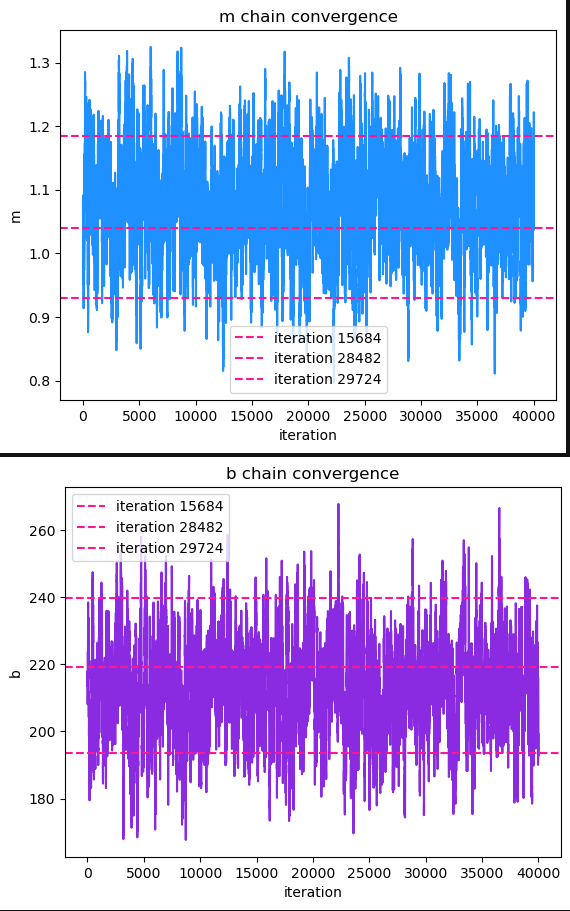

In the dashed pink lines are 3 random chains. I then plot these same chains over the data. Theya re there I promise I guess I just rolled well.

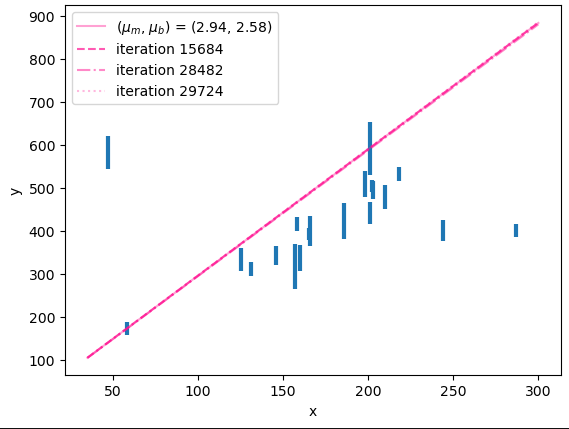

### Posterior Distributions

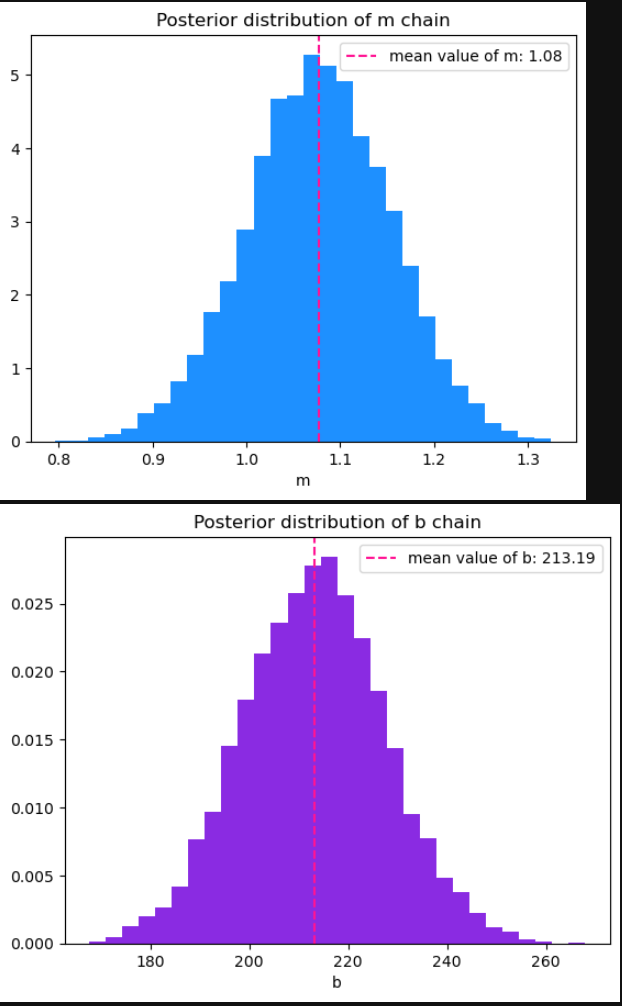

With mean values of b = 213.63 and m = 1.08, these are near spot on with the linear regression! (b = 213.27, m = 1.08).

# Part 2: 3D MCMC with GAIA Data

#### 1. Select only the stars from the data set with parallax > 40 mas.

By applying a mask to the data it went from

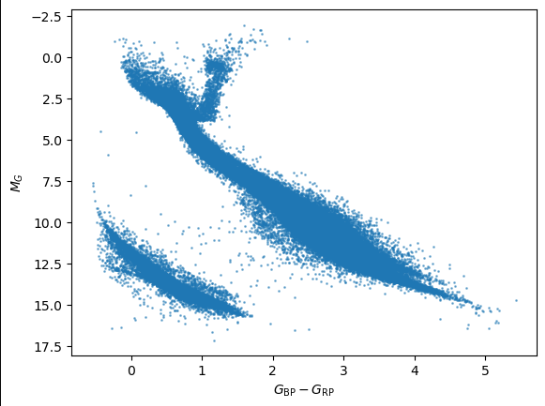

to

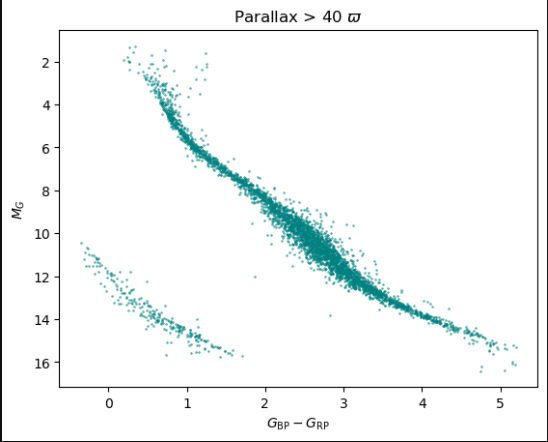

#### 2. (crudely) remove the white dwarfs (constructing a dividing line by eye is fine for this).

This may have been the excercise that made me really truly get working with dataframes. I spent a while working on this mask but now I could recreate in my sleep I feel.

Before getting started, I indentified the minimum color $G_{BP}-G_{RP}$ and maximum magnitude $M_G$ to be approximately $ -0.4$ and $16.5$ respectively. This gives us the lower bounds for the "white dwarf box."

The "white dwarf box" is where we send the offending dots. How dare they exist and break from the status quo. An offending dot can be identified by meeting the condition thats color must be between (-0.4, 2) and its magnitude must *ALSO* be between (10, 16.5) simultaneously. I made a data mask that did that :).

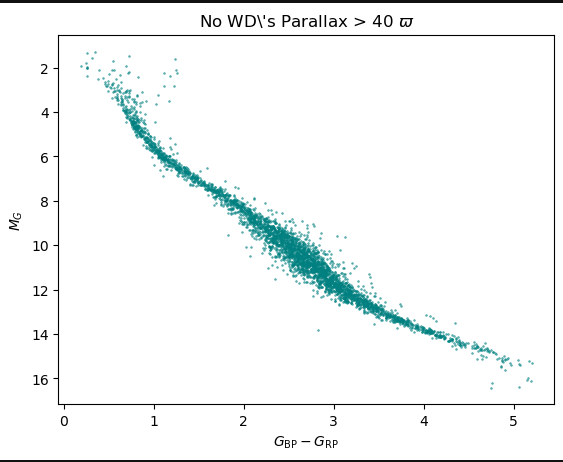

Also, you cant see it but I made the dots stars too. For fun.

#### 3. Define your likelihood. 

I redfined the liklihood with minor tweaks. I left `sigma_y` non-default and I multiply the sum by $N$ which is defined as the length of the data in y (magnitude).

#### 4. Define priors.

This is best summed up here in the code.

```
x = nearby_nowd_df['bp_rp']
y = nearby_nowd_df['mg']
m0 = 4.0
b0 = -1.0

sigma_mg_prior = stats.halfnorm.rvs(loc=10,scale=5)
```

#### 5. Baby's First 3D MCMC

and boy was I a baby. Lots of bugs to hunt and kill. Plus a typo in the liklihood function that haunted me for way too long.

But I got it!

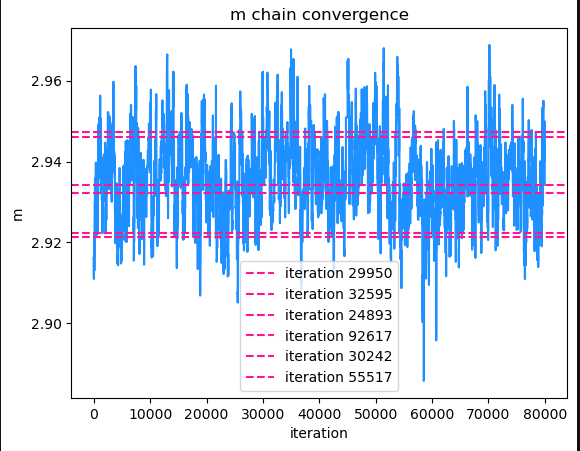
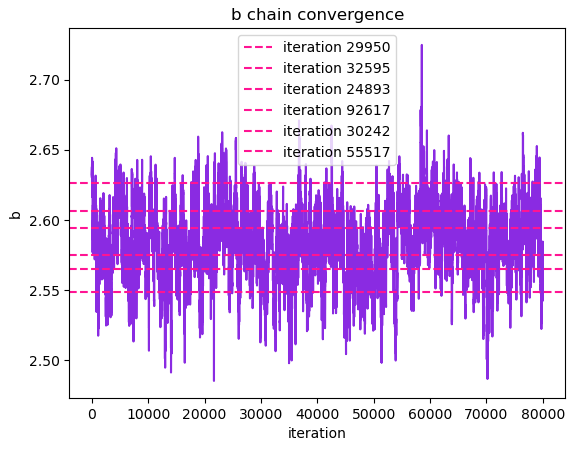
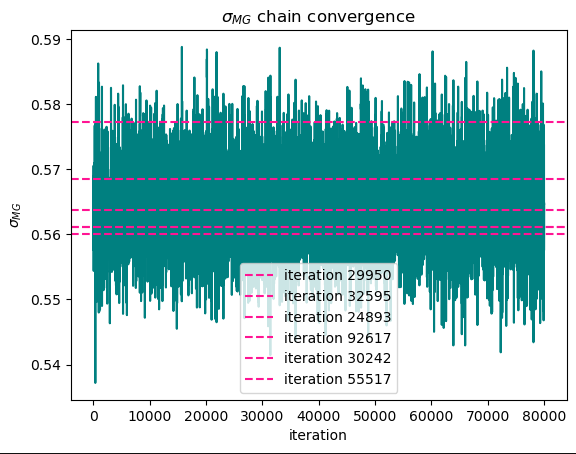

Again, I swear they are there. The MCMC just did too well to tell.
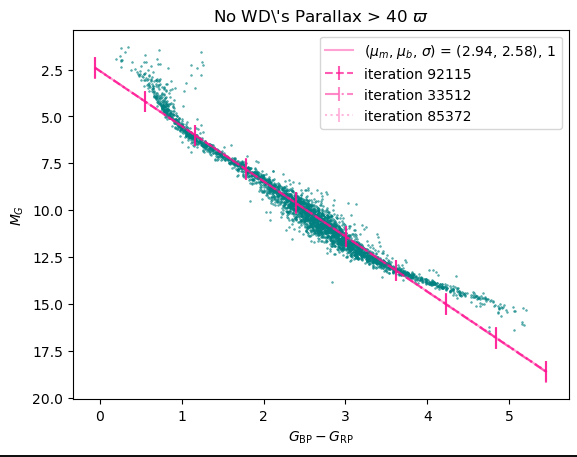

#### 6. Covariance
yes! There is!

We can check the covariance matrix!

$$\sigma_{jk} = \sqrt{[F^{-1}]_{jk}}, $$

where

$$ F_{jk} = - \frac{\partial^2}{\partial\theta_j} \frac{\ln L}{\partial\theta_k} \Biggr\rvert_{\theta=\hat \theta}$$

An numpy makes it even easier with `np.corrcoef` which outputs...

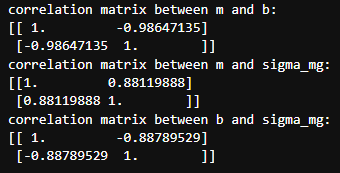

##### 7. What did we infer regarding the scatter about the line, $\sigma_{M_G}$, and how does it compare to your by-eye assessment of the width of the scatter along the main sequence?

According to MCMC, the mean value of $\sigma_{MG} = 0.59$. By visual inspection, there are--give or take-- about as many data points on either side of the trend line in the regions the linear fit is most in line with the data. If anything, it is skewed so that--thought it is roughly even--there are slightly more datapoints below the trend line which is in line with the std dev calculated by MCMC.